# Week 6 — Two Q-learners in the Prisoner's Dilemma

*Companion to the Week-6 chapter (`Topics/06.md`, §4). The chapter explains `Dolgopolov (2024)`'s analytical result; this notebook runs the smallest possible version of his setup so you can **see what happens when two learners face each other in the PD with and without memory**.*

## What Dolgopolov asks, and why

For the rest of this week, the papers either bolt an LLM onto an RL learner (`Xu`, `FAIR`) or use deep RL on networks of humans (`McKee`). `Dolgopolov` does the opposite — strip everything away, leaving only the simplest possible learner, and ask:

> *Can two memoryless learners playing the Prisoner's Dilemma ever cooperate?*

The Prisoner's Dilemma is the canonical test for any theory of cooperation. Played once, both players defect — it is the unique Nash equilibrium. Played *repeatedly* by agents who can condition on history, cooperation can emerge (e.g. *tit-for-tat*; `Axelrod 1984`). The question Dolgopolov asks is more demanding: **what if the agents cannot remember anything at all?**

His answer is a closed-form characterisation. We will not reproduce his proof, but we will reproduce the two endpoints that frame it:

1. **No memory, naive learning** &mdash; two stateless Q-learners lock into mutual defection. Easy to show; mathematically inevitable.
2. **One bit of memory, plus the shadow of the future** &mdash; cooperation becomes sustainable.

Dolgopolov's actual contribution sits *between* these two endpoints &mdash; an analytical regime where cooperation is achievable even without memory, but only in the long-run stochastic limit, and only under a specific relationship between learning rate and payoffs. The chapter explains what that result *says*; this notebook builds the algorithmic intuition by showing the two endpoints.

## The game

Each round, both players simultaneously choose **Cooperate** or **Defect**. Payoffs follow the standard Prisoner's Dilemma ordering $T > R > P > S$:

| | opponent C | opponent D |
|---|---|---|
| **I cooperate (C)** | $R$ &mdash; reward for mutual cooperation | $S$ &mdash; sucker's payoff |
| **I defect (D)** | $T$ &mdash; temptation | $P$ &mdash; punishment for mutual defection |

We use $T=5$, $R=3$, $P=1$, $S=0$ (Axelrod's standard tournament values).

- The **socially best** outcome is mutual C: both get $R = 3$.
- The **Nash equilibrium** is mutual D: both get $P = 1$. Defection is a dominant strategy.
- The **temptation gap** is $T - R = 2$ &mdash; what you gain by defecting if your partner cooperates.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

T, R, P, S = 5, 3, 1, 0

# Rows: my action. Cols: opponent action. 0 = Cooperate, 1 = Defect.
PAYOFFS = np.array([
    [R, S],   # I cooperate
    [T, P],   # I defect
])

def round_payoffs(a, b):
    """Returns (payoff to A, payoff to B) given their actions."""
    return PAYOFFS[a, b], PAYOFFS[b, a]


print("PAYOFFS matrix (rows = me, cols = opponent):")
print(PAYOFFS)
print()
print(f"  (C, C) → {round_payoffs(0, 0)}   ← socially best")
print(f"  (D, D) → {round_payoffs(1, 1)}   ← Nash equilibrium")
print(f"  (C, D) → {round_payoffs(0, 1)}   ← I cooperate, opp defects (sucker)")
print(f"  (D, C) → {round_payoffs(1, 0)}   ← I defect, opp cooperates (temptation)")

PAYOFFS matrix (rows = me, cols = opponent):
[[3 0]
 [5 1]]

  (C, C) → (np.int64(3), np.int64(3))   ← socially best
  (D, D) → (np.int64(1), np.int64(1))   ← Nash equilibrium
  (C, D) → (np.int64(0), np.int64(5))   ← I cooperate, opp defects (sucker)
  (D, C) → (np.int64(5), np.int64(0))   ← I defect, opp cooperates (temptation)


## The stateless agent — a Q-learner with no memory

The agent keeps **two numbers** &mdash; one for each action &mdash; that estimate "how much reward will I get if I take this action?" Call them $Q_C$ and $Q_D$.

Each round it:

1. **Picks** the action with the higher $Q$, with a small chance $\epsilon$ of picking randomly instead (*exploration*).
2. **Observes** the payoff.
3. **Nudges** the $Q$ value for the action it just took, toward the payoff it just observed:

$$Q_a \;\leftarrow\; Q_a \;+\; \alpha \cdot (\text{payoff} - Q_a)$$

That is the entire algorithm. $\alpha$ is the **learning rate** &mdash; how much weight to put on the new observation vs. what you already believed. With $\alpha = 1$ you replace your belief entirely each round; with $\alpha = 0$ you never learn.

**No memory.** The agent does not see who its partner was, what they just did, or what either of them did last round. The only state it carries is the two-number table $(Q_C, Q_D)$. It cannot run *tit-for-tat*, *grim trigger*, or any other strategy that conditions on the past.

In [2]:
class StatelessQLearner:
    """Two Q-values, one per action. No memory."""

    def __init__(self, lr=0.05, eps=0.05, rng=None):
        self.rng = rng or np.random.default_rng()
        # Tiny init noise so argmax doesn't always pick action 0
        self.Q = 1e-4 * self.rng.standard_normal(2)
        self.lr = lr
        self.eps = eps

    def act(self):
        if self.rng.random() < self.eps:
            return int(self.rng.integers(2))     # explore
        return int(np.argmax(self.Q))            # exploit

    def learn(self, action, payoff):
        # the one-line update
        self.Q[action] += self.lr * (payoff - self.Q[action])

## Why a stateless learner should defect — one step of arithmetic

Before running anything, look at what the algorithm is doing one round at a time.

Suppose my partner cooperates with probability $p$. Then over many rounds:

- The average payoff I get for cooperating is $\mathbb{E}[Q_C] = p \cdot R + (1-p) \cdot S = 3p$.
- The average payoff I get for defecting is $\mathbb{E}[Q_D] = p \cdot T + (1-p) \cdot P = 5p + (1-p) = 1 + 4p$.
- So $\mathbb{E}[Q_D] - \mathbb{E}[Q_C] = 1 + p > 0$, **whatever $p$ is**.

The Q-learning update is correct, in the narrow sense that it converges to the expected reward of each action. That expected reward says: *defect, always*. There is no value of $p$ that flips the comparison &mdash; not even $p = 1$ (a partner who always cooperates), because the temptation $T$ is larger than the cooperation reward $R$.

So we expect: two stateless Q-learners, regardless of learning rate, will both find their way to mutual defection. Let's verify.

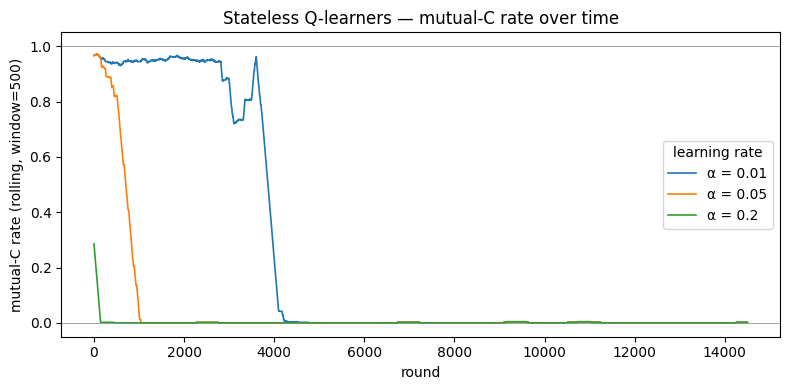

In [3]:
def play_stateless(lr=0.05, eps=0.05, n_rounds=15000, seed=0):
    """Two stateless Q-learners play n_rounds of the PD. Return action history."""
    rng = np.random.default_rng(seed)
    a = StatelessQLearner(lr=lr, eps=eps, rng=rng)
    b = StatelessQLearner(lr=lr, eps=eps, rng=rng)

    history = np.zeros((n_rounds, 2), dtype=int)
    for t in range(n_rounds):
        ai, bi = a.act(), b.act()
        pa, pb = round_payoffs(ai, bi)
        a.learn(ai, pa)
        b.learn(bi, pb)
        history[t] = (ai, bi)
    return history


def rolling_mutual_C(history, window=500):
    """Rolling fraction of rounds with mutual cooperation."""
    mutual_C = (history == 0).all(axis=1).astype(float)
    return np.convolve(mutual_C, np.ones(window) / window, mode='valid')


# Three different learning rates — does it matter?
fig, ax = plt.subplots(figsize=(8, 4))
for lr in [0.01, 0.05, 0.2]:
    hist = play_stateless(lr=lr, eps=0.05, n_rounds=15000, seed=0)
    ax.plot(rolling_mutual_C(hist), label=f"α = {lr}", lw=1.2)

ax.set_title("Stateless Q-learners — mutual-C rate over time")
ax.set_xlabel("round")
ax.set_ylabel("mutual-C rate (rolling, window=500)")
ax.set_ylim(-0.05, 1.05)
ax.legend(title="learning rate")
ax.axhline(0, color='grey', lw=0.5)
ax.axhline(1, color='grey', lw=0.5)
plt.tight_layout()
plt.show()

**As predicted.** Whatever learning rate we pick, two stateless Q-learners converge to mutual defection within a few hundred rounds. The residual "cooperation" you see is just the noise floor &mdash; both agents simultaneously firing an $\epsilon$-exploration into C.

## What if we add one bit of memory?

Now give each agent a single piece of state: **what did the opponent do last round?** That is enough to support strategies like *tit-for-tat* (cooperate if opp cooperated last round, defect if opp defected).

We also change one thing in the update. Instead of nudging $Q$ toward the immediate payoff, we nudge it toward the immediate payoff *plus* the best value we can imagine getting from the next state:

$$Q(s, a) \;\leftarrow\; Q(s, a) \;+\; \alpha \cdot \Big( \underbrace{\text{payoff}}_{\text{now}} \;+\; \underbrace{\gamma \cdot \max_{a'} Q(s', a')}_{\text{future, discounted}} \;-\; Q(s, a) \Big)$$

The $\gamma$ is a **discount factor** in $[0, 1)$ &mdash; how much we care about future rewards relative to present ones. This is what game theorists call the **shadow of the future**. With $\gamma > 0$, an action that *leads* to a good state becomes valuable, not just an action that immediately pays.

We also start each agent with **optimistic initialisation** ($Q = 10$ for every $(s, a)$): assume things will be great, get disappointed by experience. This is a standard way to encourage exploration in tabular Q-learning (`Sutton & Barto 2018`, §2.6).

In [4]:
class StatefulQLearner:
    """One bit of memory: opponent's last action. Two actions. Discounted Q-learning."""

    def __init__(self, lr=0.01, eps=0.02, gamma=0.95, rng=None, optimistic_init=10.0):
        self.rng = rng or np.random.default_rng()
        # Q[state, action] — state ∈ {0=opp last C, 1=opp last D}
        self.Q = np.full((2, 2), float(optimistic_init))
        self.lr = lr
        self.eps = eps
        self.gamma = gamma
        self.last_opp = 0
        self._prev_s, self._prev_a = 0, None

    def act(self):
        s = self.last_opp
        a = int(self.rng.integers(2)) if self.rng.random() < self.eps else int(np.argmax(self.Q[s]))
        self._prev_s, self._prev_a = s, a
        return a

    def learn(self, payoff, opp_action):
        # bootstrap from the best value reachable in the next state
        target = payoff + self.gamma * np.max(self.Q[opp_action])
        self.Q[self._prev_s, self._prev_a] += self.lr * (target - self.Q[self._prev_s, self._prev_a])
        self.last_opp = opp_action


def play_stateful(lr=0.01, eps=0.02, gamma=0.95, n_rounds=15000, seed=0):
    rng = np.random.default_rng(seed)
    a = StatefulQLearner(lr=lr, eps=eps, gamma=gamma, rng=rng)
    b = StatefulQLearner(lr=lr, eps=eps, gamma=gamma, rng=rng)

    history = np.zeros((n_rounds, 2), dtype=int)
    for t in range(n_rounds):
        ai, bi = a.act(), b.act()
        pa, pb = round_payoffs(ai, bi)
        a.learn(pa, bi)
        b.learn(pb, ai)
        history[t] = (ai, bi)
    return history, a, b

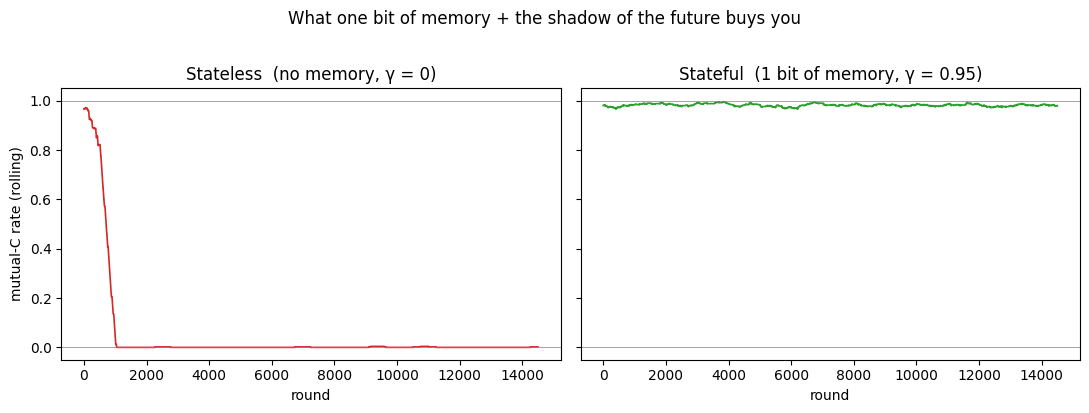

Agent A's Q-table after training:
                         action C    action D
  state: opp last C  →   56.031     42.743
  state: opp last D  →   41.485     10.000

Greedy policy: if opp last played C → play C.  If opp last played D → play C.


In [5]:
# Side-by-side: stateless vs stateful (1 bit + γ-discount)
fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

# left — stateless
hist_sl = play_stateless(lr=0.05, eps=0.05, n_rounds=15000, seed=0)
ax[0].plot(rolling_mutual_C(hist_sl), lw=1.2, color='C3')
ax[0].set_title("Stateless  (no memory, γ = 0)")
ax[0].set_xlabel("round")
ax[0].set_ylabel("mutual-C rate (rolling)")

# right — stateful + discounted
hist_st, agent_a, agent_b = play_stateful(lr=0.01, eps=0.02, gamma=0.95, n_rounds=15000, seed=0)
ax[1].plot(rolling_mutual_C(hist_st), lw=1.2, color='C2')
ax[1].set_title("Stateful  (1 bit of memory, γ = 0.95)")
ax[1].set_xlabel("round")

for a_ in ax:
    a_.set_ylim(-0.05, 1.05)
    a_.axhline(0, color='grey', lw=0.5)
    a_.axhline(1, color='grey', lw=0.5)

plt.suptitle("What one bit of memory + the shadow of the future buys you", y=1.02)
plt.tight_layout()
plt.show()

# Inspect the learned Q-table — what strategy did agent A discover?
print("Agent A's Q-table after training:")
print("                         action C    action D")
print(f"  state: opp last C  →  {agent_a.Q[0, 0]:7.3f}    {agent_a.Q[0, 1]:7.3f}")
print(f"  state: opp last D  →  {agent_a.Q[1, 0]:7.3f}    {agent_a.Q[1, 1]:7.3f}")
best_C = 'C' if agent_a.Q[0, 0] > agent_a.Q[0, 1] else 'D'
best_D = 'C' if agent_a.Q[1, 0] > agent_a.Q[1, 1] else 'D'
print(f"\nGreedy policy: if opp last played C → play {best_C}.  If opp last played D → play {best_D}.")

**The contrast is the lesson.** Two stateless agents lock into mutual defection. Two agents with one bit of memory and a discount factor settle into mutual cooperation.

Look at the learned $Q$-table for the *opp-last-C* state — both values are large (around 56 vs 43), and $Q_C > Q_D$. That is the engine of the cooperative equilibrium: each agent's best response to *opp just cooperated* is to cooperate too, and they sustain it for thousands of rounds. The values in the *opp-last-D* row are less informative — once cooperation locks in, that state is rarely visited, so its $Q$-values mostly reflect the optimistic initial guess (10) rather than learned experience. (That is why the printed "greedy policy" reads as *always C* rather than as a punishing tit-for-tat — the punishment branch never gets exercised enough to learn that defecting against a defector is the right move.)

Two things did the work:

1. **Conditioning on the partner.** A stateless agent cannot distinguish "opp just defected" from "opp just cooperated." A stateful one can, in principle, punish defection and reward cooperation — which is what makes cooperation strategically rational for the partner to choose in the first place.
2. **Caring about the future.** With $\gamma > 0$, an action that *leads* to a cooperative state is valuable in itself. Without $\gamma$, the temptation payoff $T$ always wins right now — even in the stateful version.

## So what did Dolgopolov actually prove?

What we just demonstrated — *cooperation is achievable when agents have memory and care about the future* — has been known since `Axelrod (1984)`. It is the textbook story.

Dolgopolov's contribution is to push the question *back* to the harder version: **can cooperation emerge even without memory, and even without explicit discounting**? His answer is yes, but only in the **long-run stochastic limit**, and only under a specific relationship between the **learning rate** $\alpha$ and the **temptation gap** $T - R$. The proof uses the machinery of stochastic stability in matching games (`Newton & Sawa 2015`).

Why this matters:

- **Naive simulation will not show it cleanly.** As we just saw, two stateless Q-learners with finite-sample noise lock into defection in a few hundred rounds. Dolgopolov's regime is asymptotic — noise → 0, time → ∞, in a specific order.
- **A closed form is what regulators can quote.** Algorithmic-pricing collusion in markets (`Calvano et al. 2020`) is exactly this question with different cover. "When do two pricing bots tacitly collude?" becomes a sharp condition on algorithm parameters rather than a simulation.
- **It is a no-memory result.** Calvano-style algorithmic-collusion simulations typically use Q-learners *with* state. Dolgopolov asks whether the memoryless special case — sometimes invoked as the "safe" version — is really safe.

## What this notebook showed — and what it didn't

**What we built.**

- The simplest reinforcement learner: one number per action, nudge it toward the payoff you got. Twelve lines.
- The simplest extension: one bit of state plus a discount factor. Another twelve lines.
- Two two-line proofs by simulation: stateless agents defect; stateful + discounting agents cooperate.

**What we did *not* do.**

- **No reproduction of Dolgopolov's phase diagram.** The analytical regime he characterises is in the long-run stochastic-stability limit, not the finite-sample one we simulate.
- **No deep networks.** The PPO/MAPPO of `Xu et al. (2024)` and the deep RL of `McKee et al. (2023)` swap the tabular Q for a neural network. The phase-diagram intuition is what survives the scaling-up.
- **No closed form.** We *observed* the difference between stateless and stateful; Dolgopolov *characterises* the stateless case analytically. The proof is the paper's contribution &mdash; not the existence of the effect.

**Where this leaves us for the rest of the week.** Dolgopolov is the purist paper of Week 6: no language, no humans, no memory. It draws the lower bound for what RL alone can do in a classical game. Read it against `McKee et al.` (where RL designs the institution humans play in) and against `Xu et al.` (where RL picks among LLM-generated candidates). The same algorithmic kernel &mdash; *nudge the value of the action you took toward the payoff you got* &mdash; runs underneath all three.

## References

- Dolgopolov, A. (2024). Reinforcement learning in a Prisoner's Dilemma. *Games and Economic Behavior*.
- Newton, J. & Sawa, R. (2015). A one-shot deviation principle for stability in matching problems. *Journal of Economic Theory*.
- Calvano, E., Calzolari, G., Denicolò, V. & Pastorello, S. (2020). Artificial intelligence, algorithmic pricing, and collusion. *American Economic Review*.
- Axelrod, R. (1984). *The Evolution of Cooperation*. Basic Books.
- Roth, A. E. & Erev, I. (1995). Learning in extensive-form games. *Games and Economic Behavior*.
- Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press.